In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 56.9 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mne


In [ ]:
!wget -O S001R01.edf \
https://physionet.org/files/eegmmidb/1.0.0/S001/S001R01.edf

--2026-09-09 06:46:38--  https://physionet.org/files/eegmmidb/1.0.0/S001/S001R01.edf
Resolving physionet.org (physionet.org)... 18.25.8.254
Connecting to physionet.org (physionet.org)|18.25.8.254|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1275936 (1.2M) [application/octet-stream]
Saving to: ‘S001R01.edf’

S001R01.edf         100%[===================>]   1.22M   167KB/s    in 6.8s    

2026-09-09 06:46:46 (183 KB/s) - ‘S001R01.edf’ saved [1275936/1275936]



In [ ]:
raw = mne.io.read_raw_edf(
    "S001R01.edf",
    preload=True,
    verbose=False
)

print(raw)

<RawEDF | S001R01.edf, 64 x 9760 (61.0 s), ~4.8 MiB, data loaded>


Using matplotlib as 2D backend.


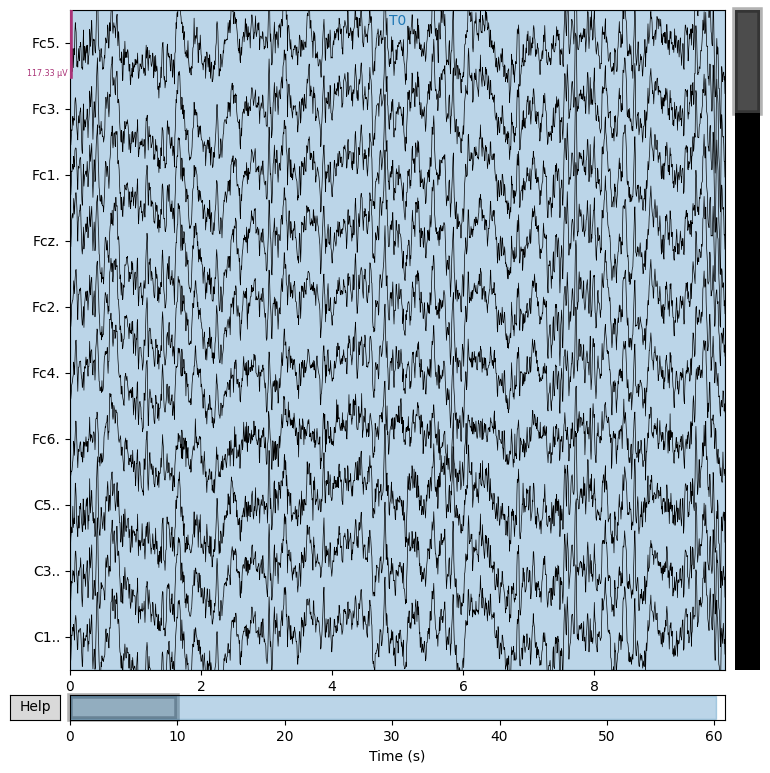

In [ ]:
raw.plot(
    duration=10,
    n_channels=10,
    scalings="auto"
)
plt.show()

In [ ]:
raw.pick("eeg")

print(raw.info)


<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1057 samples (6.606 s)



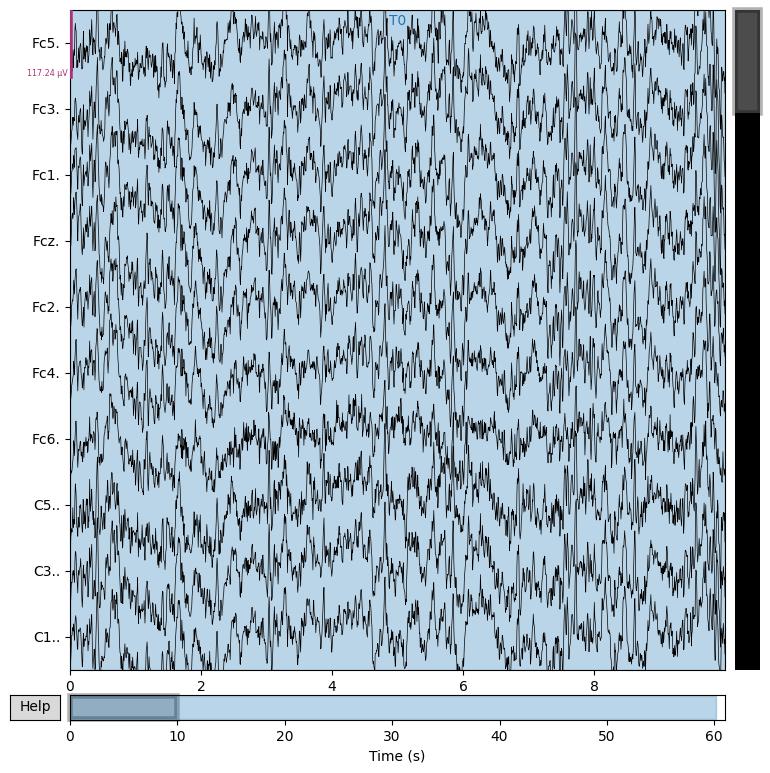

In [ ]:
raw_notch = raw.copy()
raw_notch.notch_filter(freqs=50)

raw_notch.plot(
    duration=10,
    n_channels=10,
    scalings="auto"
)

plt.show()


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)



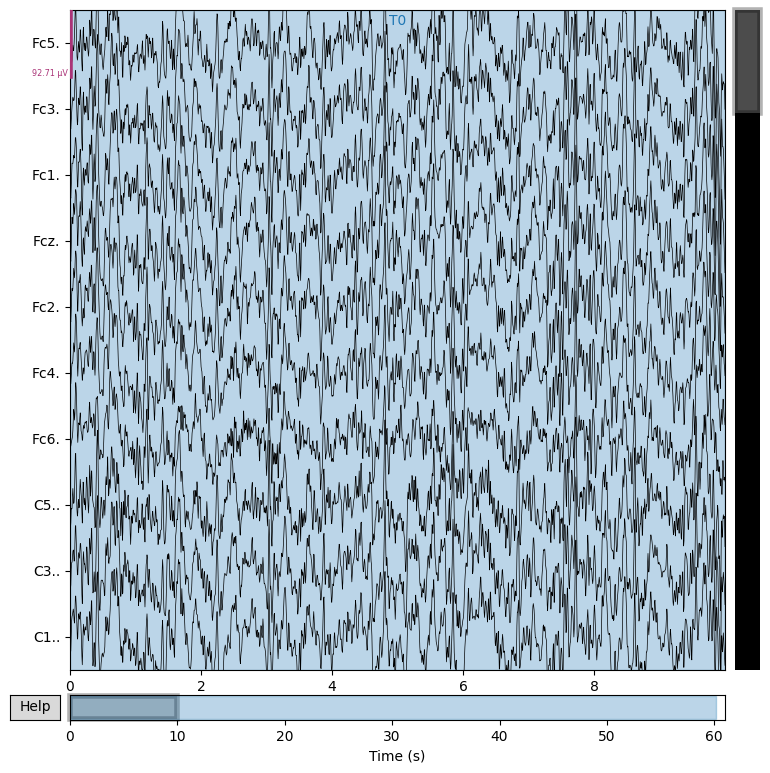

In [ ]:
raw_band = raw_notch.copy()

raw_band.filter(
    l_freq=1,
    h_freq=40
)

raw_band.plot(
    duration=10,
    n_channels=10,
    scalings="auto"
)

plt.show()

In [ ]:
data = raw_band.get_data()

print("Maximum amplitude:",
      np.max(np.abs(data)))

Maximum amplitude: 0.0006132629874716943


In [ ]:
epochs = mne.make_fixed_length_epochs(
    raw_band,
    duration=2.0,
    preload=True
)

print(epochs)

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 320 original time points ...
0 bad epochs dropped
<Epochs | 30 events (all good), 0 – 1.994 s (baseline off), ~4.7 MiB, data loaded,
 '1': 30>


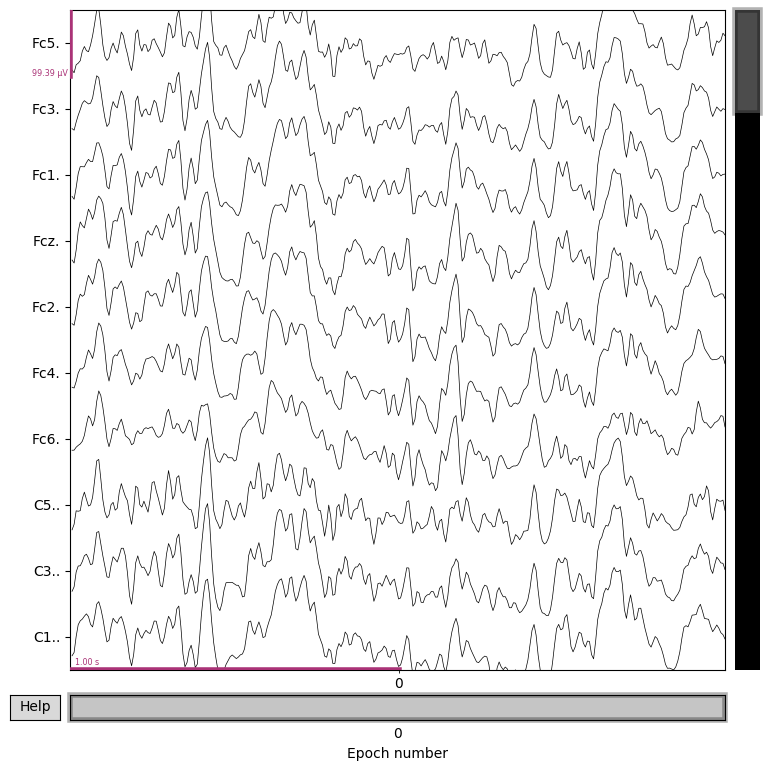

In [ ]:
epochs[0].plot(
    n_channels=10,
    scalings="auto"
)

plt.show()

In [ ]:
X = epochs.get_data()

X_normalized = (
    X - X.mean(axis=2, keepdims=True)
) / (
    X.std(axis=2, keepdims=True) + 1e-8
)

print(X_normalized.shape)

(30, 64, 320)


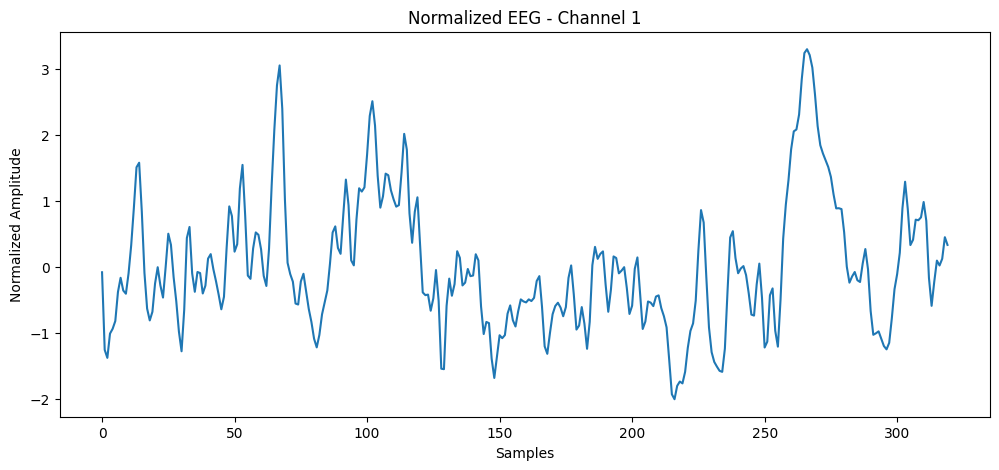

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    X_normalized[0, 0, :]
)

plt.title("Normalized EEG - Channel 1")
plt.xlabel("Samples")
plt.ylabel("Normalized Amplitude")

plt.show()

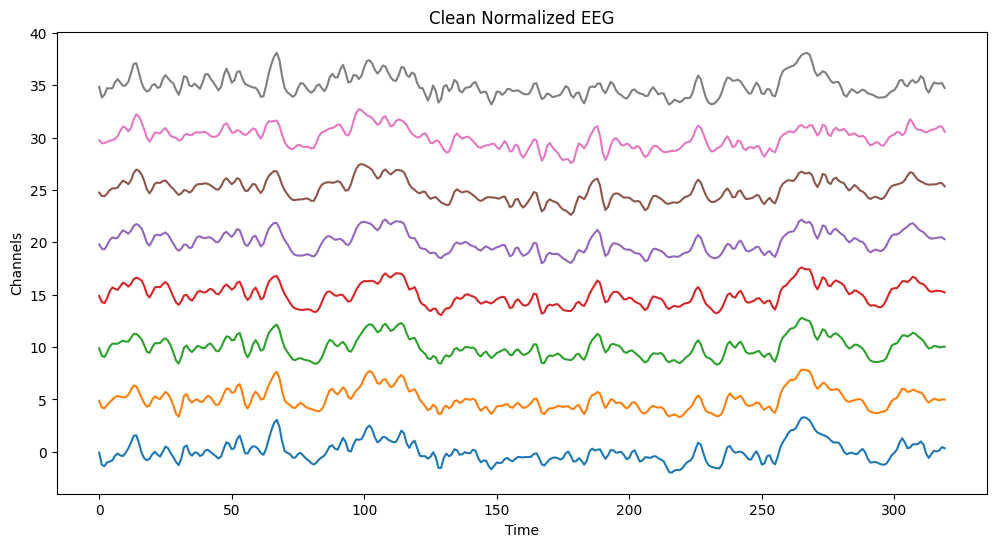

In [ ]:
epoch = X_normalized[0]

plt.figure(figsize=(12, 6))

for ch in range(min(8, epoch.shape[0])):
    plt.plot(
        epoch[ch] + ch * 5
    )

plt.title("Clean Normalized EEG")
plt.xlabel("Time")
plt.ylabel("Channels")

plt.savefig(
    "eeg_clean_image.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()